# Sampling Distribution and Its Parameters

**Date:** March 24, 2026

**Experiment Title:** Sampling Distribution and Its Parameters

## Aim
To study sampling distribution and its parameters.

## Software
Google Colab / Jupyter Notebook

## Theory
This experiment explores different types of sampling distributions:
- **Sampling Distribution of the mean**: Distribution of sample means from repeated random sampling
- **Sampling Distribution of the proportion**: Distribution of sample proportions from repeated random sampling
- **Sampling Distribution of the difference between two means**: Distribution of differences between means of two sample groups
- **Sampling Distribution of the difference between two proportions**: Distribution of differences between proportions of two sample groups

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Implementation 1: Sampling Distribution of the Mean

**Scenario:** A company produces light bulbs with a lifespan that follows a normal distribution. The mean lifespan is 1200 hours with a standard deviation of 200 hours. A quality control team randomly selects 36 bulbs. Determine the mean and standard deviation of the sampling distribution.

SAMPLING DISTRIBUTION OF THE MEAN - LIGHT BULBS

Population Parameters:
  Population Mean (μ): 1200 hours
  Population Standard Deviation (σ): 200 hours
  Sample Size (n): 36

Theoretical Sampling Distribution Parameters:
  Mean of Sampling Distribution (μₓ̄): 1200 hours
  Standard Error (σₓ̄ = σ/√n): 33.3333 hours

Empirical Values (from 10000 simulated samples):
  Mean of Sample Means: 1199.8778 hours
  Standard Error (empirical): 33.4103 hours


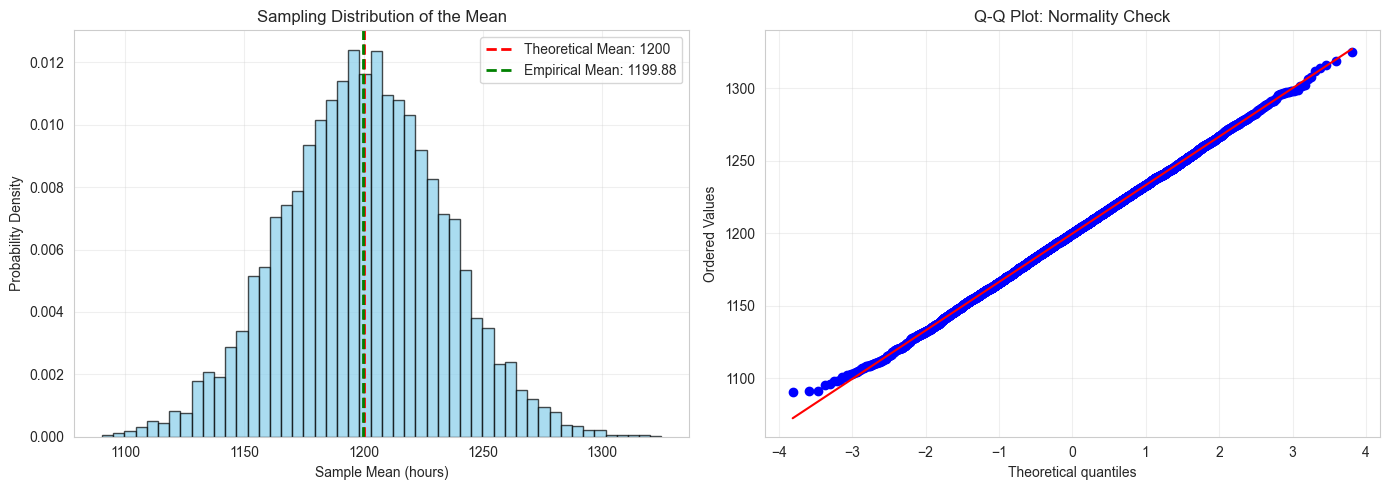


✓ Sampling distribution follows a normal distribution (as expected)


In [2]:
# Parameters
population_mean = 1200  # hours
population_std = 200    # hours
sample_size = 36

# Theoretical values for sampling distribution of the mean
theoretical_mean = population_mean
theoretical_std_error = population_std / np.sqrt(sample_size)

print("=" * 60)
print("SAMPLING DISTRIBUTION OF THE MEAN - LIGHT BULBS")
print("=" * 60)
print(f"\nPopulation Parameters:")
print(f"  Population Mean (μ): {population_mean} hours")
print(f"  Population Standard Deviation (σ): {population_std} hours")
print(f"  Sample Size (n): {sample_size}")

print(f"\nTheoretical Sampling Distribution Parameters:")
print(f"  Mean of Sampling Distribution (μₓ̄): {theoretical_mean} hours")
print(f"  Standard Error (σₓ̄ = σ/√n): {theoretical_std_error:.4f} hours")

# Simulate sampling distribution by taking multiple samples
num_samples = 10000
sample_means = []

for _ in range(num_samples):
    sample = np.random.normal(population_mean, population_std, sample_size)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

# Empirical values
empirical_mean = np.mean(sample_means)
empirical_std_error = np.std(sample_means, ddof=1)

print(f"\nEmpirical Values (from {num_samples} simulated samples):")
print(f"  Mean of Sample Means: {empirical_mean:.4f} hours")
print(f"  Standard Error (empirical): {empirical_std_error:.4f} hours")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of sample means
axes[0].hist(sample_means, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(theoretical_mean, color='red', linestyle='--', linewidth=2, label=f'Theoretical Mean: {theoretical_mean}')
axes[0].axvline(empirical_mean, color='green', linestyle='--', linewidth=2, label=f'Empirical Mean: {empirical_mean:.2f}')
axes[0].set_xlabel('Sample Mean (hours)')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Sampling Distribution of the Mean')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(sample_means, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Normality Check')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Sampling distribution follows a normal distribution (as expected)")


## Implementation 2: Sampling Distribution of the Proportion

**Scenario:** A survey reports that 55% of customers prefer online shopping over physical stores. A marketing agency randomly samples 400 customers. Find the mean and standard deviation of the sampling distribution of the proportion.


SAMPLING DISTRIBUTION OF THE PROPORTION - ONLINE SHOPPING

Population Parameters:
  Population Proportion (p): 0.55
  Sample Size (n): 400

Theoretical Sampling Distribution Parameters:
  Mean of Sampling Distribution (μₚ): 0.55
  Standard Error (σₚ = √[p(1-p)/n]): 0.024875

Empirical Values (from 10000 simulated samples):
  Mean of Sample Proportions: 0.550009
  Standard Error (empirical): 0.024724


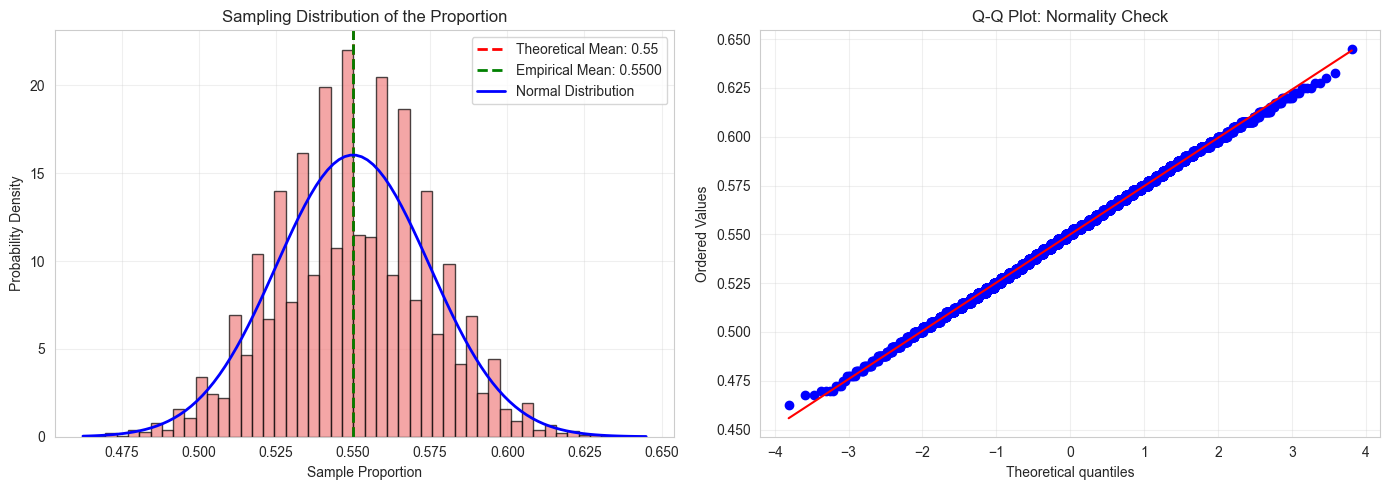


✓ Test for sufficient sample size (n*p and n*(1-p)):
  n*p = 220.0 > 5 ✓
  n*(1-p) = 180.0 > 5 ✓
✓ Sampling distribution is approximately normal


In [3]:
# Parameters
population_proportion = 0.55  # 55% prefer online shopping
sample_size_prop = 400

# Theoretical values for sampling distribution of the proportion
theoretical_mean_prop = population_proportion
theoretical_std_error_prop = np.sqrt((population_proportion * (1 - population_proportion)) / sample_size_prop)

print("\n" + "=" * 60)
print("SAMPLING DISTRIBUTION OF THE PROPORTION - ONLINE SHOPPING")
print("=" * 60)
print(f"\nPopulation Parameters:")
print(f"  Population Proportion (p): {population_proportion}")
print(f"  Sample Size (n): {sample_size_prop}")

print(f"\nTheoretical Sampling Distribution Parameters:")
print(f"  Mean of Sampling Distribution (μₚ): {theoretical_mean_prop}")
print(f"  Standard Error (σₚ = √[p(1-p)/n]): {theoretical_std_error_prop:.6f}")

# Simulate sampling distribution of proportions
num_samples = 10000
sample_proportions = []

for _ in range(num_samples):
    # Generate sample: 1 = prefer online, 0 = prefer physical
    sample = np.random.binomial(1, population_proportion, sample_size_prop)
    sample_prop = np.mean(sample)
    sample_proportions.append(sample_prop)

sample_proportions = np.array(sample_proportions)

# Empirical values
empirical_mean_prop = np.mean(sample_proportions)
empirical_std_error_prop = np.std(sample_proportions, ddof=1)

print(f"\nEmpirical Values (from {num_samples} simulated samples):")
print(f"  Mean of Sample Proportions: {empirical_mean_prop:.6f}")
print(f"  Standard Error (empirical): {empirical_std_error_prop:.6f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of sample proportions
axes[0].hist(sample_proportions, bins=50, density=True, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0].axvline(theoretical_mean_prop, color='red', linestyle='--', linewidth=2, label=f'Theoretical Mean: {theoretical_mean_prop}')
axes[0].axvline(empirical_mean_prop, color='green', linestyle='--', linewidth=2, label=f'Empirical Mean: {empirical_mean_prop:.4f}')

# Overlay normal distribution
x = np.linspace(sample_proportions.min(), sample_proportions.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, theoretical_mean_prop, theoretical_std_error_prop), 
             'b-', linewidth=2, label='Normal Distribution')

axes[0].set_xlabel('Sample Proportion')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Sampling Distribution of the Proportion')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(sample_proportions, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Normality Check')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Test for sufficient sample size (n*p and n*(1-p)):")
print(f"  n*p = {sample_size_prop * population_proportion:.1f} > 5 ✓")
print(f"  n*(1-p) = {sample_size_prop * (1 - population_proportion):.1f} > 5 ✓")
print("✓ Sampling distribution is approximately normal")


## Implementation 3: Sampling Distribution of the Difference Between Two Means

**Scenario:** A study compares the heights of male and female students. The mean height of males is 175 cm with a standard deviation of 10 cm, while for females, it is 165 cm with a standard deviation of 8 cm. Random samples of 50 males and 40 females are selected. Find the mean and standard deviation of the sampling distribution of the difference.


SAMPLING DISTRIBUTION OF DIFFERENCE BETWEEN TWO MEANS - HEIGHTS

Population Parameters:
  Males:   Mean = 175 cm, SD = 10 cm, n = 50
  Females: Mean = 165 cm, SD = 8 cm, n = 40

Theoretical Sampling Distribution Parameters:
  Mean of Difference (μ₁ - μ₂): 10 cm
  Standard Error of Difference (σ₁₋₂):
    = √[(σ₁²/n₁) + (σ₂²/n₂)]
    = √[(10²/50) + (8²/40)]
    = 1.8974 cm

Empirical Values (from 10000 simulated samples):
  Mean of Differences: 9.9991 cm
  Standard Error (empirical): 1.8997 cm


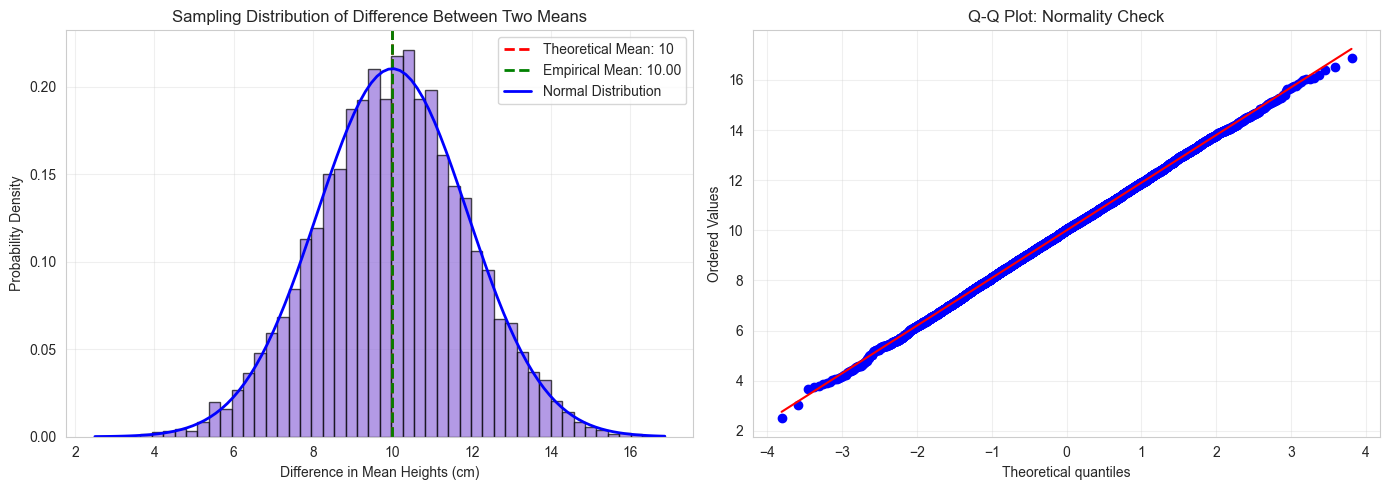


✓ Sampling distribution follows a normal distribution (as expected)


In [4]:
# Parameters
mean_male = 175      # cm
std_male = 10        # cm
n_male = 50

mean_female = 165    # cm
std_female = 8       # cm
n_female = 40

# Theoretical values for sampling distribution of the difference between means
theoretical_mean_diff = mean_male - mean_female
theoretical_std_diff = np.sqrt((std_male**2 / n_male) + (std_female**2 / n_female))

print("\n" + "=" * 60)
print("SAMPLING DISTRIBUTION OF DIFFERENCE BETWEEN TWO MEANS - HEIGHTS")
print("=" * 60)
print(f"\nPopulation Parameters:")
print(f"  Males:   Mean = {mean_male} cm, SD = {std_male} cm, n = {n_male}")
print(f"  Females: Mean = {mean_female} cm, SD = {std_female} cm, n = {n_female}")

print(f"\nTheoretical Sampling Distribution Parameters:")
print(f"  Mean of Difference (μ₁ - μ₂): {theoretical_mean_diff} cm")
print(f"  Standard Error of Difference (σ₁₋₂):")
print(f"    = √[(σ₁²/n₁) + (σ₂²/n₂)]")
print(f"    = √[({std_male}²/{n_male}) + ({std_female}²/{n_female})]")
print(f"    = {theoretical_std_diff:.4f} cm")

# Simulate sampling distribution of differences
num_samples = 10000
sample_mean_diffs = []

for _ in range(num_samples):
    sample_male = np.random.normal(mean_male, std_male, n_male)
    sample_female = np.random.normal(mean_female, std_female, n_female)
    mean_diff = np.mean(sample_male) - np.mean(sample_female)
    sample_mean_diffs.append(mean_diff)

sample_mean_diffs = np.array(sample_mean_diffs)

# Empirical values
empirical_mean_diff = np.mean(sample_mean_diffs)
empirical_std_diff = np.std(sample_mean_diffs, ddof=1)

print(f"\nEmpirical Values (from {num_samples} simulated samples):")
print(f"  Mean of Differences: {empirical_mean_diff:.4f} cm")
print(f"  Standard Error (empirical): {empirical_std_diff:.4f} cm")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of differences
axes[0].hist(sample_mean_diffs, bins=50, density=True, alpha=0.7, color='mediumpurple', edgecolor='black')
axes[0].axvline(theoretical_mean_diff, color='red', linestyle='--', linewidth=2, label=f'Theoretical Mean: {theoretical_mean_diff}')
axes[0].axvline(empirical_mean_diff, color='green', linestyle='--', linewidth=2, label=f'Empirical Mean: {empirical_mean_diff:.2f}')

# Overlay normal distribution
x = np.linspace(sample_mean_diffs.min(), sample_mean_diffs.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, theoretical_mean_diff, theoretical_std_diff), 
             'b-', linewidth=2, label='Normal Distribution')

axes[0].set_xlabel('Difference in Mean Heights (cm)')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Sampling Distribution of Difference Between Two Means')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(sample_mean_diffs, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Normality Check')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Sampling distribution follows a normal distribution (as expected)")


## Implementation 4: Sampling Distribution of the Difference Between Two Proportions

**Scenario:** A study examines voting preferences between two cities. In City A, 60% of people support a candidate, while in City B, 50% support the same candidate. A sample of 500 people from each city is taken. Find the mean and standard deviation of the sampling distribution of the difference.


SAMPLING DISTRIBUTION OF DIFFERENCE BETWEEN TWO PROPORTIONS - VOTING

Population Parameters:
  City A: Proportion = 0.6, Sample Size = 500
  City B: Proportion = 0.5, Sample Size = 500

Theoretical Sampling Distribution Parameters:
  Mean of Difference (p₁ - p₂): 0.09999999999999998
  Standard Error of Difference (σₚ₁₋ₚ₂):
    = √[(p₁(1-p₁)/n₁) + (p₂(1-p₂)/n₂)]
    = √[(0.6*0.4/500) + (0.5*0.5/500)]
    = 0.031305

Empirical Values (from 10000 simulated samples):
  Mean of Differences: 0.099860
  Standard Error (empirical): 0.030972


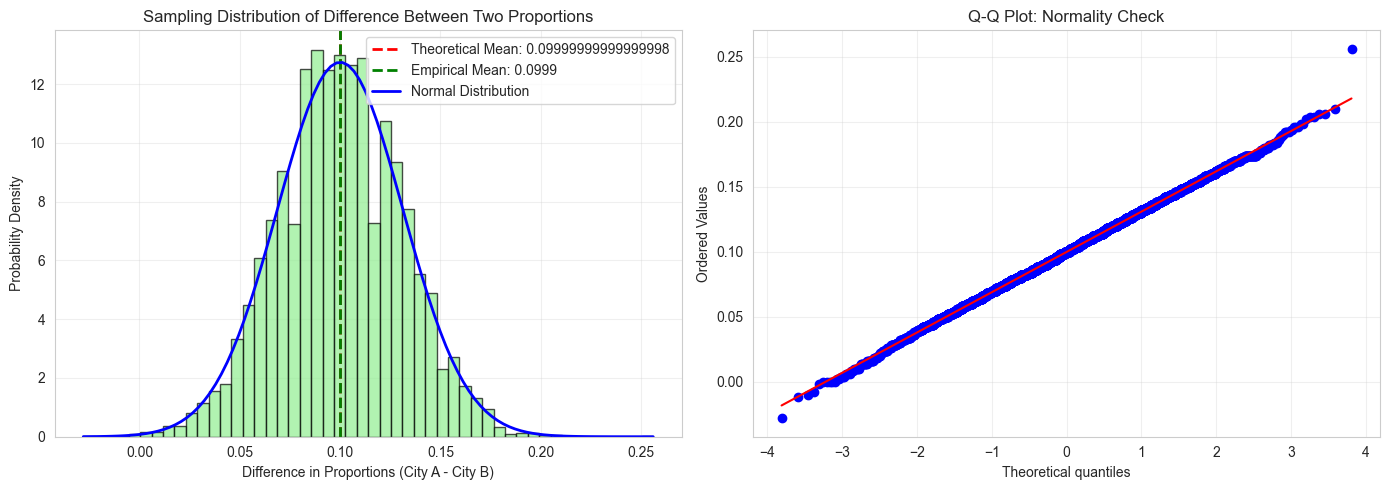


✓ Check for sufficient sample sizes:
  City A - n₁*p₁ = 300.0 > 5 ✓
  City A - n₁*(1-p₁) = 200.0 > 5 ✓
  City B - n₂*p₂ = 250.0 > 5 ✓
  City B - n₂*(1-p₂) = 250.0 > 5 ✓
✓ Sampling distribution is approximately normal


In [5]:
# Parameters
p_city_a = 0.60  # 60% support in City A
p_city_b = 0.50  # 50% support in City B
n_city_a = 500
n_city_b = 500

# Theoretical values for sampling distribution of difference between proportions
theoretical_mean_prop_diff = p_city_a - p_city_b
theoretical_std_prop_diff = np.sqrt((p_city_a * (1 - p_city_a) / n_city_a) + 
                                     (p_city_b * (1 - p_city_b) / n_city_b))

print("\n" + "=" * 60)
print("SAMPLING DISTRIBUTION OF DIFFERENCE BETWEEN TWO PROPORTIONS - VOTING")
print("=" * 60)
print(f"\nPopulation Parameters:")
print(f"  City A: Proportion = {p_city_a}, Sample Size = {n_city_a}")
print(f"  City B: Proportion = {p_city_b}, Sample Size = {n_city_b}")

print(f"\nTheoretical Sampling Distribution Parameters:")
print(f"  Mean of Difference (p₁ - p₂): {theoretical_mean_prop_diff}")
print(f"  Standard Error of Difference (σₚ₁₋ₚ₂):")
print(f"    = √[(p₁(1-p₁)/n₁) + (p₂(1-p₂)/n₂)]")
print(f"    = √[({p_city_a}*{1-p_city_a}/{n_city_a}) + ({p_city_b}*{1-p_city_b}/{n_city_b})]")
print(f"    = {theoretical_std_prop_diff:.6f}")

# Simulate sampling distribution of differences between proportions
num_samples = 10000
sample_prop_diffs = []

for _ in range(num_samples):
    sample_a = np.random.binomial(1, p_city_a, n_city_a)
    sample_b = np.random.binomial(1, p_city_b, n_city_b)
    prop_a = np.mean(sample_a)
    prop_b = np.mean(sample_b)
    prop_diff = prop_a - prop_b
    sample_prop_diffs.append(prop_diff)

sample_prop_diffs = np.array(sample_prop_diffs)

# Empirical values
empirical_mean_prop_diff = np.mean(sample_prop_diffs)
empirical_std_prop_diff = np.std(sample_prop_diffs, ddof=1)

print(f"\nEmpirical Values (from {num_samples} simulated samples):")
print(f"  Mean of Differences: {empirical_mean_prop_diff:.6f}")
print(f"  Standard Error (empirical): {empirical_std_prop_diff:.6f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of differences
axes[0].hist(sample_prop_diffs, bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0].axvline(theoretical_mean_prop_diff, color='red', linestyle='--', linewidth=2, 
                label=f'Theoretical Mean: {theoretical_mean_prop_diff}')
axes[0].axvline(empirical_mean_prop_diff, color='green', linestyle='--', linewidth=2, 
                label=f'Empirical Mean: {empirical_mean_prop_diff:.4f}')

# Overlay normal distribution
x = np.linspace(sample_prop_diffs.min(), sample_prop_diffs.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, theoretical_mean_prop_diff, theoretical_std_prop_diff), 
             'b-', linewidth=2, label='Normal Distribution')

axes[0].set_xlabel('Difference in Proportions (City A - City B)')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Sampling Distribution of Difference Between Two Proportions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(sample_prop_diffs, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Normality Check')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Check for sufficient sample sizes:")
print(f"  City A - n₁*p₁ = {n_city_a * p_city_a:.1f} > 5 ✓")
print(f"  City A - n₁*(1-p₁) = {n_city_a * (1 - p_city_a):.1f} > 5 ✓")
print(f"  City B - n₂*p₂ = {n_city_b * p_city_b:.1f} > 5 ✓")
print(f"  City B - n₂*(1-p₂) = {n_city_b * (1 - p_city_b):.1f} > 5 ✓")
print("✓ Sampling distribution is approximately normal")


## Conclusion

Thus, we have successfully studied sampling distributions and their parameters. Through this experiment, we explored:

1. **Sampling Distribution of the Mean**: Verified that sample means from a normal population distribution also follow a normal distribution with mean equal to the population mean and standard error = σ/√n.

2. **Sampling Distribution of the Proportion**: Confirmed that sample proportions follow an approximately normal distribution (when sample size is sufficiently large) with mean equal to the population proportion and standard error = √[p(1-p)/n].

3. **Sampling Distribution of the Difference Between Two Means**: Demonstrated that the difference between two sample means follows a normal distribution with mean = μ₁ - μ₂ and standard error = √[(σ₁²/n₁) + (σ₂²/n₂)].

4. **Sampling Distribution of the Difference Between Two Proportions**: Showed that the difference between two sample proportions follows an approximately normal distribution with mean = p₁ - p₂ and standard error = √[(p₁(1-p₁)/n₁) + (p₂(1-p₂)/n₂)].

### Key Takeaways:
- All sampling distributions were verified to follow normal distributions (confirmed by Q-Q plots)
- Theoretical values closely matched empirical values from simulations
- Understanding sampling distributions is crucial for hypothesis testing and confidence interval estimation
- Sample size plays a critical role in the precision of sample statistics (as shown by standard error calculations)

**Date Completed:** March 24, 2026